In [2]:
import pandas as pd
import glob
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
regions_path = "/home/aegis/Titan1/NRAD/data/Regions_ver2"
data_regions_path = "/home/aegis/Titan1/NRAD/data/Regions_data"

SCALAR_VARS = ["met_recalc_pt", "met_recalc_phi", "weight_phys"]
VECTOR_VARS = ["AnalysisJetsAuxDyn_pt", "AnalysisJetsAuxDyn_eta", "AnalysisJetsAuxDyn_phi", 
               "AnalysisLargeRJetsAuxDyn_pt", "AnalysisLargeRJetsAuxDyn_eta", "AnalysisLargeRJetsAuxDyn_phi",
               "AnalysisLargeRJetsAuxDyn_Tau1_wta", "AnalysisLargeRJetsAuxDyn_Tau2_wta", "AnalysisLargeRJetsAuxDyn_Tau3_wta", 
               ]

columns_to_load = SCALAR_VARS + VECTOR_VARS


MC_NEW_HLVS = [
    "ht",
    "met_recalc_pt", 
    "mjj", 
    "pt_balance", 
    "dphi_j1_j2", 
    "ljet1_tau21", "ljet1_tau32", 
    "ljet2_tau21", "ljet2_tau32", 
    "min_dphi_jet_met", 
    "weight_phys"
]
DATA_NEW_HLVS = [
    "ht",
    "met_recalc_pt", 
    "mjj", 
    "pt_balance", 
    "dphi_j1_j2", 
    "ljet1_tau21", "ljet1_tau32", 
    "ljet2_tau21", "ljet2_tau32", 
    "min_dphi_jet_met"
]
# "CR_emu", 
MC_SAMPLES = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]

context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

In [ ]:
def delta_phi(phi1, phi2):
    # The standard "wrap-around" logic
    dphi = (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi
    return dphi
def prepare_events(events):

    jets = ak.zip({
        "pt": events["AnalysisJetsAuxDyn_pt"],
        "eta": events["AnalysisJetsAuxDyn_eta"],
        "phi": events["AnalysisJetsAuxDyn_phi"],
        "mass": ak.zeros_like(events["AnalysisJetsAuxDyn_pt"])
    }, with_name="Momentum4D")

    ljs = ak.zip({
        "pt": events["AnalysisLargeRJetsAuxDyn_pt"],
        "tau1": events["AnalysisLargeRJetsAuxDyn_Tau1_wta"],
        "tau2": events["AnalysisLargeRJetsAuxDyn_Tau2_wta"],
        "tau3": events["AnalysisLargeRJetsAuxDyn_Tau3_wta"]
    })

    met = ak.zip({
        "pt": events["met_recalc_pt"],
        "phi": events["met_recalc_phi"]
    }, with_name="Momentum2D")


    events["ht"] = ak.sum(events["AnalysisJetsAuxDyn_pt"], axis=1)/1000

    j_lead = jets[:, 0]
    j_sub  = jets[:, 1]

    events["mjj"] = np.sqrt(2 * j_lead.pt * j_sub.pt * (np.cosh(j_lead.eta - j_sub.eta) - np.cos(j_lead.phi - j_sub.phi)))/1000

    met_phi = events["met_recalc_phi"]
    # We need to broadcast MET phi to match the shape of the jet array for subtraction
    # e.g., if Event 1 has 3 jets, we need [met_phi, met_phi, met_phi]
    jet_phi = events["AnalysisJetsAuxDyn_phi"]
    met_phi_broadcasted = ak.broadcast_arrays(met_phi, jet_phi)[0]

    # B. Calculate dPhi between ALL jets and MET
    dphi_jet_met = np.abs(delta_phi(jet_phi, met_phi_broadcasted))

    # --- Save Variable: Min dPhi(Jet, MET) ---
    events["min_dphi_jet_met"] = ak.min(dphi_jet_met, axis=1)

    idx_closest = ak.argmin(dphi_jet_met, axis=1, keepdims=True)
    idx_farthest = ak.argmax(dphi_jet_met, axis=1, keepdims=True)

    # D. Extract pt and phi for these specific jets
    # syntax: array[indices] gives us the specific values
    pt_closest = events["AnalysisJetsAuxDyn_pt"][idx_closest][:, 0]
    phi_closest = events["AnalysisJetsAuxDyn_phi"][idx_closest][:, 0]

    pt_farthest = events["AnalysisJetsAuxDyn_pt"][idx_farthest][:, 0]
    phi_farthest = events["AnalysisJetsAuxDyn_phi"][idx_farthest][:, 0]

    # E. Calculate Vector Sum of the two jets (Numerator)
    # We add their x and y components
    vec_sum_px = (pt_closest * np.cos(phi_closest)) + (pt_farthest * np.cos(phi_farthest))
    vec_sum_py = (pt_closest * np.sin(phi_closest)) + (pt_farthest * np.sin(phi_farthest))
    vec_sum_pt = np.sqrt(vec_sum_px**2 + vec_sum_py**2)

    # F. Calculate Scalar Sum (Denominator)
    scalar_sum_pt = pt_closest + pt_farthest

    # G. Final Calculation
    # events["pt_balance"] = vec_sum_pt / scalar_sum_pt
    denom_safe = scalar_sum_pt > 0
    raw_balance = vec_sum_pt / scalar_sum_pt

    # Use ak.where to replace the bad values with 0
    # Syntax: ak.where(condition, value_if_true, value_if_false)
    events["pt_balance"] = ak.where(denom_safe, raw_balance, 0)

    events["dphi_j1_j2"] = np.abs(delta_phi(phi_closest, phi_farthest))

    # Leading Large-R Jet (Index 0)
    tau1_lead = events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, 0]
    tau2_lead = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, 0]
    tau3_lead = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, 0]

    events["ljet1_tau21"] = ak.where(tau1_lead > 0, tau2_lead / tau1_lead, 0)
    events["ljet1_tau32"] = ak.where(tau2_lead > 0, tau3_lead / tau2_lead, 0)

    # Subleading Large-R Jet (Index 1)
    tau1_sub = events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, 1]
    tau2_sub = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, 1]
    tau3_sub = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, 1]

    events["ljet2_tau21"] = ak.where(tau1_sub > 0, tau2_sub / tau1_sub, 0)
    events["ljet2_tau32"] = ak.where(tau2_sub > 0, tau3_sub / tau2_sub, 0)

    print("Calculation complete. New variables added to 'events'.")

    return events

def plot_stacked_distributions(
    dfs_dict,
    context_vars,
    feature_vars,
    data_df=None,
    bins=20,
    figsize=(18, 8),
    weight=False
):
    all_vars = context_vars + feature_vars
    n_cols = max(len(context_vars), len(feature_vars))
    n_rows = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)

    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    statistics_dict = {}

    for label, df in dfs_dict.items():
        statistics_dict[label] = 0

    
    for col, var in enumerate(all_vars):
        row = 0 if col < len(context_vars) else 1
        col_idx = col if row == 0 else col - len(context_vars)

        ax = axes[row, col_idx]

        data_list = []
        weights_list = []
        labels = []

        # --- EXTRACT DATA EARLY ---
        # We need the length of the data before we plot the MC stack
        data_values = None
        if data_df is not None and var in data_df.columns:
            data_values = data_df[var].dropna()

        # -------- MC STACK --------
        for label, df in dfs_dict.items():
            statistics_dict[label] += len(df)
            if var not in df.columns:
                continue

            values = df[var].dropna()

            if weight:
                weights = df.loc[values.index, "weight_phys"]
            else:
                weights = np.ones_like(values)

            data_list.append(values)
            weights_list.append(weights)
            labels.append(label)

        # Compute common bins
        all_values = np.concatenate([v.values for v in data_list if len(v) > 0])
        if len(all_values) == 0:
            continue

        bin_edges = np.histogram_bin_edges(all_values, bins=bins)

        # --- NORMALIZE WEIGHTS TO DATA ---
        if data_values is not None and len(data_values) > 0:
            n_data = len(data_values)
            total_mc_weight = sum(np.sum(w) for w in weights_list)
            
            # Avoid division by zero just in case
            if total_mc_weight > 0:
                scale_factor = n_data / total_mc_weight
                weights_list = [w * scale_factor for w in weights_list]

        # Plot stacked MC
        ax.hist(
            data_list,
            bins=bin_edges,
            weights=weights_list,
            stacked=True,
            label=labels
        )

        # -------- DATA OVERLAY --------
        if data_values is not None:
            counts, _ = np.histogram(data_values, bins=bin_edges)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

            # Poisson errors
            errors = np.sqrt(counts)

            ax.errorbar(
                bin_centers,
                counts,
                yerr=errors,
                fmt='o',
                color='black',
                label='Data'
            )

        # -------- STYLING --------
        if var in ["ht", "met_recalc_pt"]:
            ax.set_yscale("log")

        ax.set_title(var)
        ax.set_ylabel("Events")

        if row == 1:
            ax.set_xlabel(var)

    # Remove empty subplots
    for i in range(len(context_vars), n_cols):
        axes[0, i].axis("off")
    for i in range(len(feature_vars), n_cols):
        axes[1, i].axis("off")

    last_context_idx = len(context_vars) - 1
    axes[0, last_context_idx].legend(
        loc='upper left', 
        bbox_to_anchor=(1.05, 1), 
        borderaxespad=0.
    )

    plt.show()
    print("MC Process Statistics:")
    for label, count in statistics_dict.items():
        print(f"  {label}: {count}", "Percetage: {:.2f}%".format(100 * count / sum(statistics_dict.values())))


def load_process_df(files, is_data=False):
    events = ak.from_parquet(files, columns=columns_to_load)
    events = prepare_events(events)

    cols = DATA_NEW_HLVS if is_data else MC_NEW_HLVS
    return ak.to_dataframe(events[cols])

def plot_cr(cr_name, weight=False):
    plot_stacked_distributions(
        all_results[cr_name]["mc"],
        context_var,
        features,
        data_df=all_results[cr_name]["data"],
        weight=weight
    )


In [4]:
all_results = {}

# CRS = ["CR_emu", "CR0L", "CR1ele", "CR1eleb", "CR1mu", "CR1mub", "CR2ele", "CR2mu"]
CRS = ["CR_emu"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR_emu...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


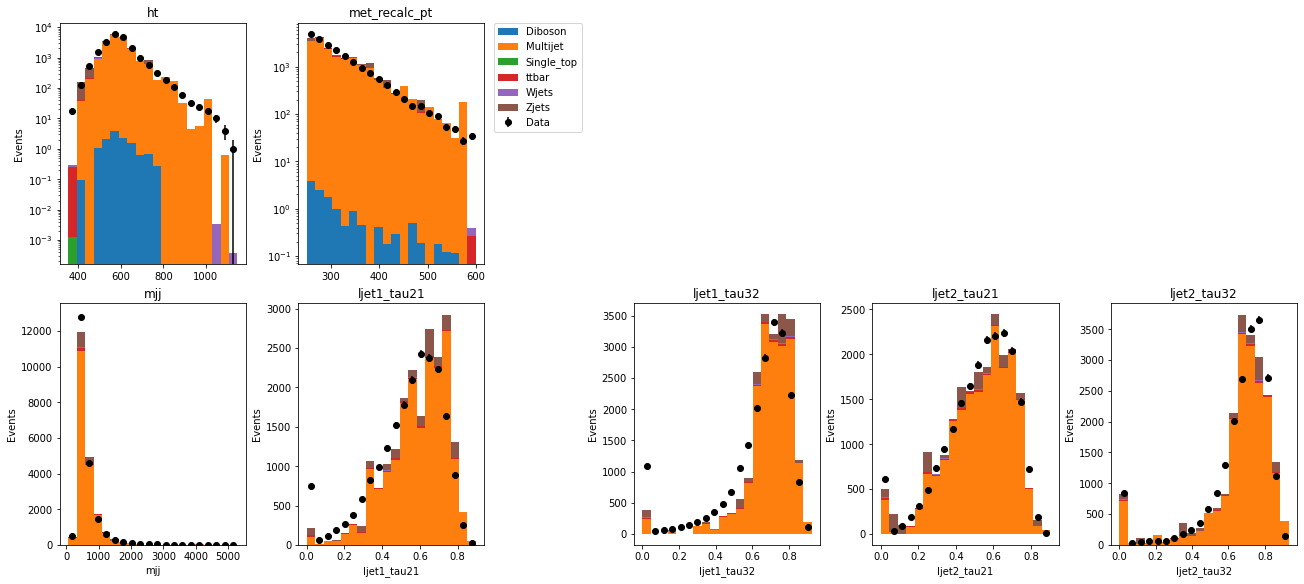

MC Process Statistics:
  Diboson: 966 Percetage: 0.34%
  Multijet: 4956 Percetage: 1.76%
  Single_top: 1043 Percetage: 0.37%
  ttbar: 6125 Percetage: 2.18%
  Wjets: 263032 Percetage: 93.67%
  Zjets: 4697 Percetage: 1.67%


In [29]:
plot_cr("CR_emu", weight=True)

In [6]:
CRS = ["CR0L"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR0L...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


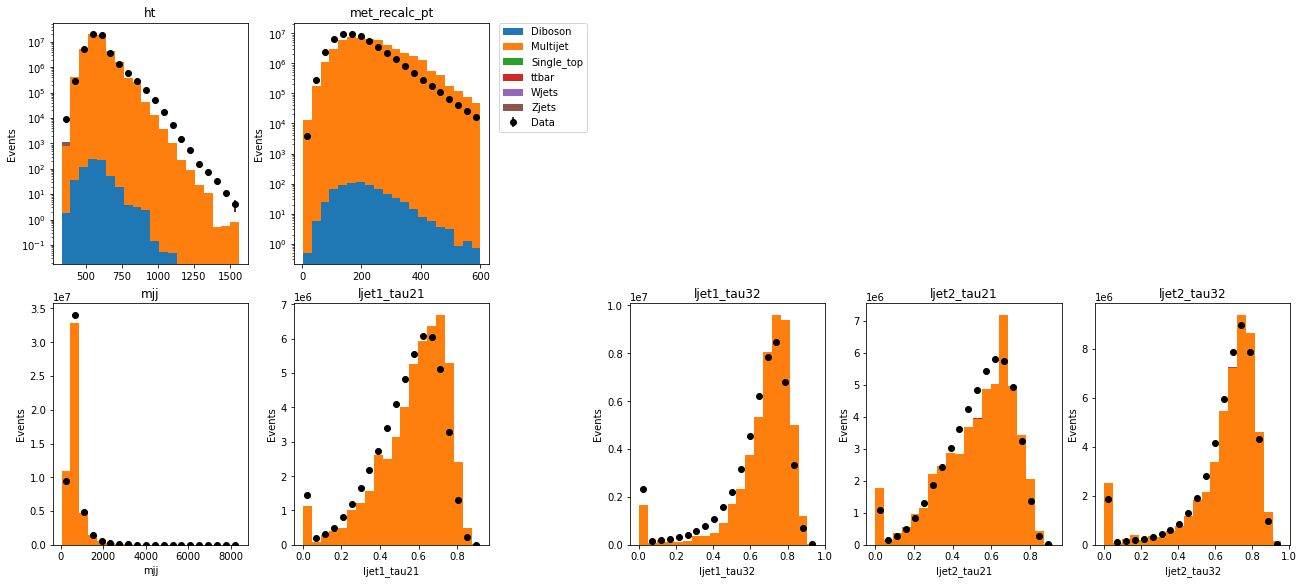

MC Process Statistics:
  Diboson: 87353 Percetage: 0.29%
  Multijet: 15483356 Percetage: 51.25%
  Single_top: 19887 Percetage: 0.07%
  ttbar: 67151 Percetage: 0.22%
  Wjets: 12884564 Percetage: 42.65%
  Zjets: 1668163 Percetage: 5.52%


In [32]:
plot_cr("CR0L", weight=True)

In [ ]:
CRS = ["CR1ele"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR1ele...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


KeyboardInterrupt: 

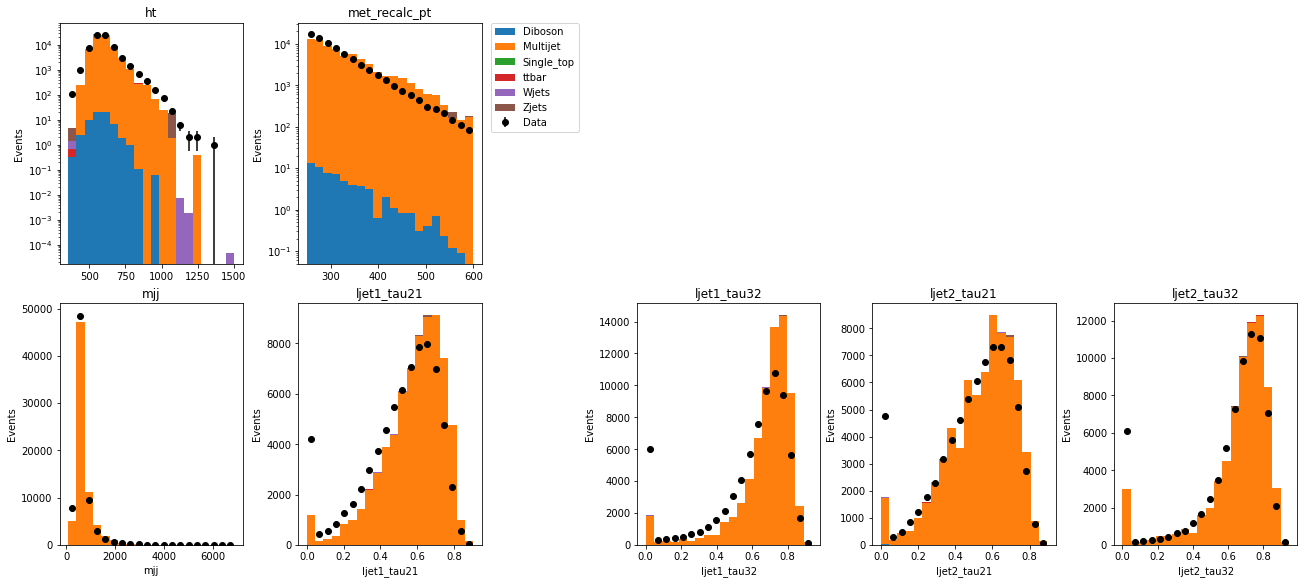

MC Process Statistics:
  Diboson: 6573 Percetage: 0.35%
  Multijet: 26929 Percetage: 1.43%
  Single_top: 700 Percetage: 0.04%
  ttbar: 1953 Percetage: 0.10%
  Wjets: 1845473 Percetage: 97.91%
  Zjets: 3255 Percetage: 0.17%


In [31]:
plot_cr("CR1ele", weight=True)

In [7]:
all_results = {}
CRS = ["CR1eleb"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR1eleb...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


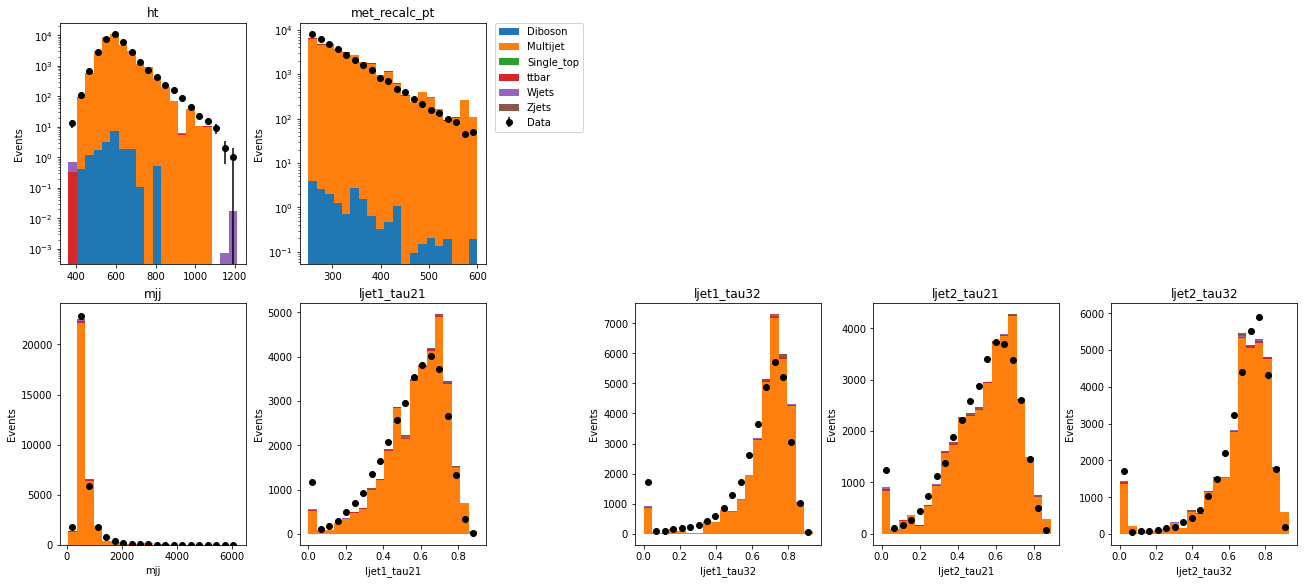

MC Process Statistics:
  Diboson: 1288 Percetage: 0.36%
  Multijet: 6860 Percetage: 1.93%
  Single_top: 2576 Percetage: 0.72%
  ttbar: 6517 Percetage: 1.83%
  Wjets: 337463 Percetage: 94.92%
  Zjets: 812 Percetage: 0.23%


In [19]:
plot_cr("CR1eleb", weight=True)

In [10]:
CRS = ["CR1mu"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR1mu...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


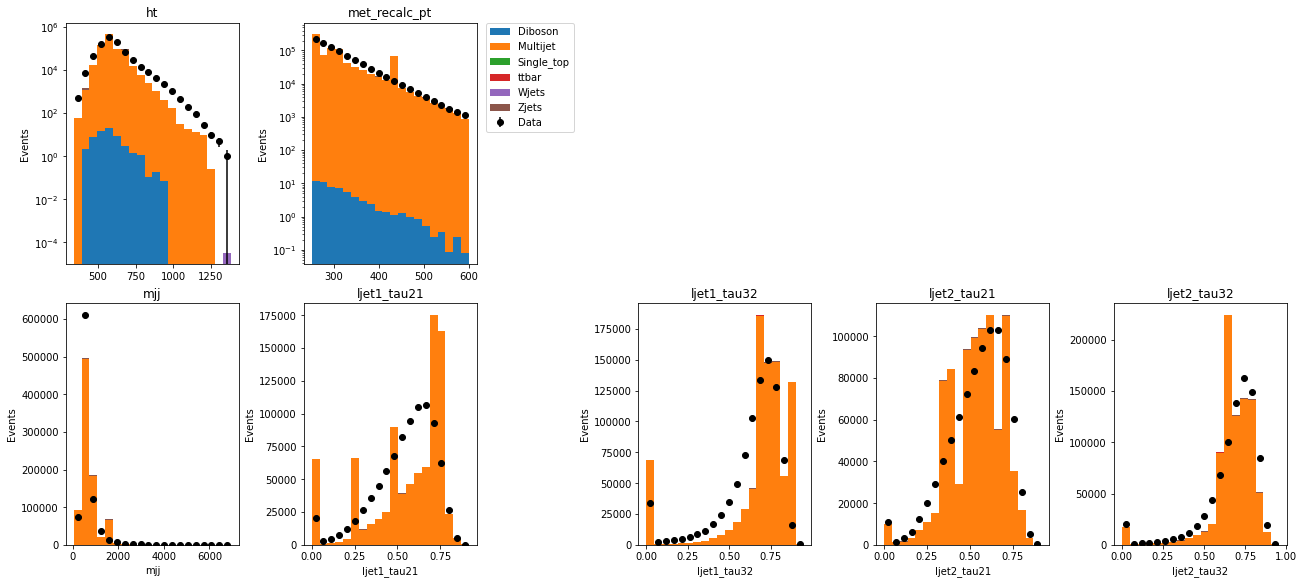

MC Process Statistics:
  Diboson: 13426 Percetage: 0.29%
  Multijet: 413889 Percetage: 8.91%
  Single_top: 1610 Percetage: 0.03%
  ttbar: 5467 Percetage: 0.12%
  Wjets: 3841404 Percetage: 82.73%
  Zjets: 367563 Percetage: 7.92%


In [16]:
plot_cr("CR1mu", weight=True)

In [12]:
CRS = ["CR1mub"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR1mub...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


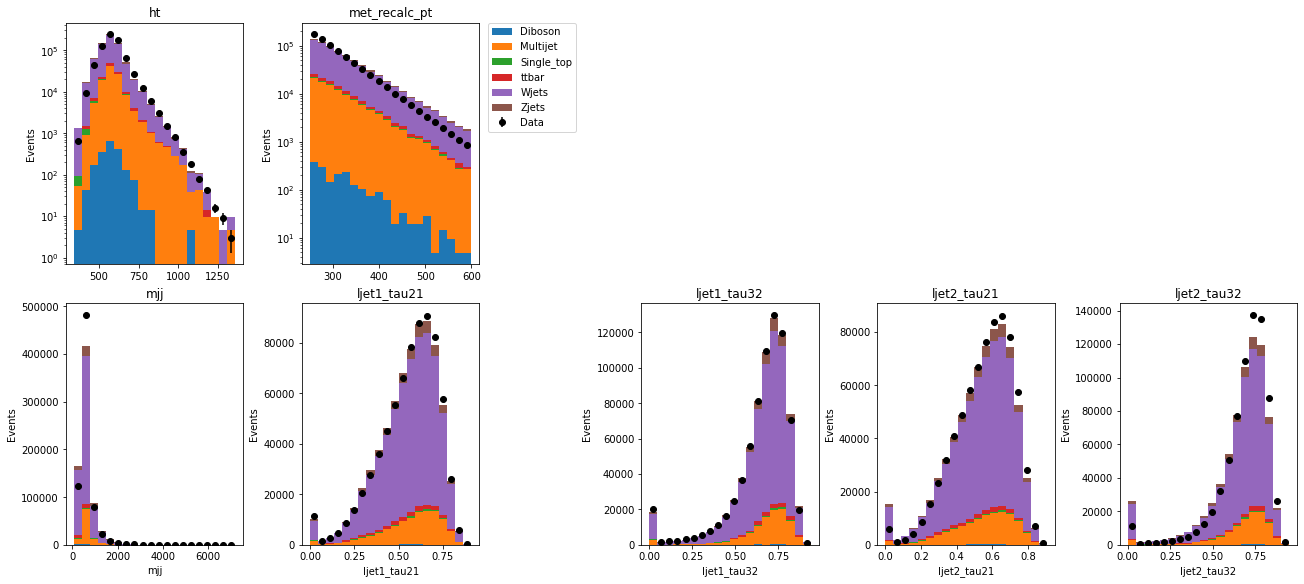

MC Process Statistics:
  Diboson: 2793 Percetage: 0.26%
  Multijet: 157689 Percetage: 14.73%
  Single_top: 7420 Percetage: 0.69%
  ttbar: 23947 Percetage: 2.24%
  Wjets: 818104 Percetage: 76.42%
  Zjets: 60634 Percetage: 5.66%


In [ ]:
plot_cr("CR1mub", weight=False)

In [ ]:
CRS = ["CR2ele"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        if len(files) == 0:
            print(f"Warning: No files found for {sample} in {cr}")
            continue
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR2ele...
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


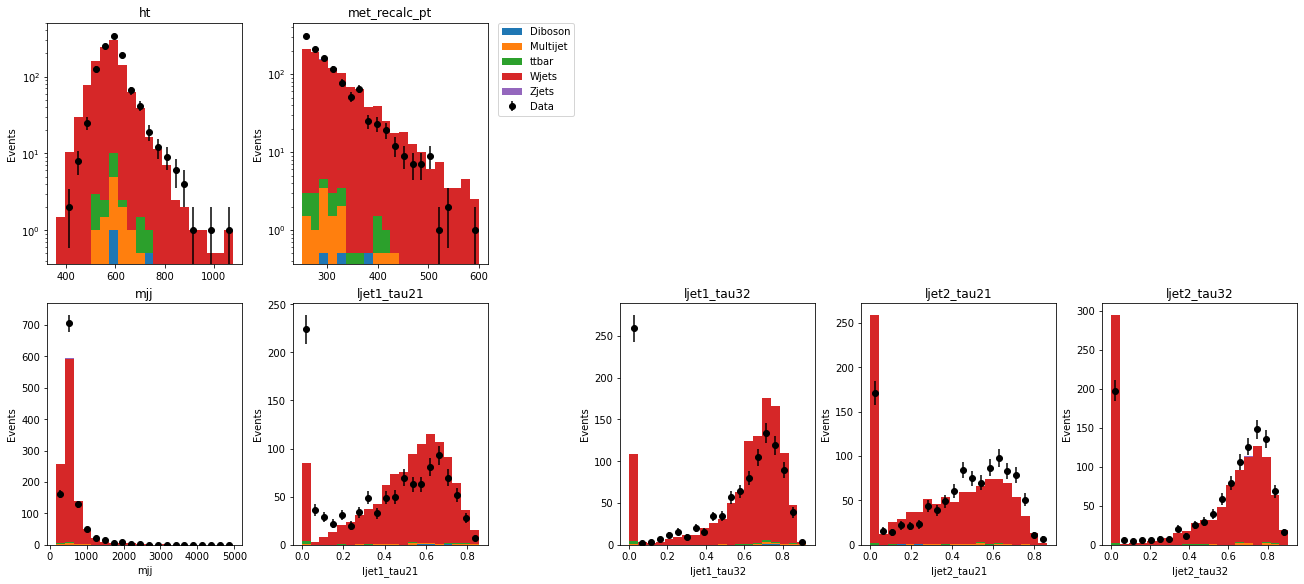

MC Process Statistics:
  Diboson: 21 Percetage: 0.14%
  Multijet: 140 Percetage: 0.91%
  ttbar: 140 Percetage: 0.91%
  Wjets: 15127 Percetage: 97.96%
  Zjets: 14 Percetage: 0.09%


In [17]:
plot_cr("CR2ele", weight=False)

In [18]:
CRS = ["CR2mu"]

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        if len(files) == 0:
            print(f"Warning: No files found for {sample} in {cr}")
            continue
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR2mu...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
